In [2]:
import sys
import re
from pathlib import Path

CODE_DIR = (Path.cwd().parent).resolve()
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from cloudprompts.evaluation import evaluate_segmentation

In [3]:
LEVEL_ROOT = Path("../inference/clipseg_cloudsen12plus_prompt_ladder").expanduser().resolve()

LEVEL_GLOB = "**/L[1-7]"


GT_DIR = Path("../data/cloudsen12plus/export_p509_high_npz/test/masks").expanduser().resolve()

OUT_DIR = (Path.cwd().resolve() / "ladder_eval").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL = "clipseg"
DATASET = "cloudsen12plus"
NUM_CLASSES = 4
CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

GT_KEY = "mask"
PRED_KEY = "mask"
GT_EXT = ".npz"
PRED_EXT = ".npz"

IGNORE_INDEX = None
STRICT = True

print("LEVEL_ROOT:", LEVEL_ROOT, "exists:", LEVEL_ROOT.exists())
print("GT_DIR    :", GT_DIR, "exists:", GT_DIR.exists())
print("OUT_DIR   :", OUT_DIR, "exists:", OUT_DIR.exists())

LEVEL_ROOT: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder exists: True
GT_DIR    : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/data/cloudsen12plus/export_p509_high_npz/test/masks exists: True
OUT_DIR   : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval exists: True


In [4]:
def discover_level_dirs():
    if "LEVEL_DIRS" in globals():
        dirs = [Path(p).expanduser().resolve() for p in LEVEL_DIRS]
    else:
        dirs = [p.resolve() for p in LEVEL_ROOT.glob(LEVEL_GLOB) if p.is_dir()]

    def level_num(p: Path) -> int:
        m = re.search(r"\bl([1-4])\b", p.name)
        if not m:
            m = re.search(r"[\\/](l[1-4])[\\/]", str(p))
        if not m:
            return 999
        return int(m.group(1)[1])

    dirs = sorted(dirs, key=level_num)
    return dirs

LEVEL_DIRS_FOUND = discover_level_dirs()
print("Found level dirs:")
for d in LEVEL_DIRS_FOUND:
    print(" -", d)


Found level dirs:
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L4
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L5
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L2
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L7
 - /Users/harshithkethavath/Library/Mobile Documents/com~apple~Clou

In [5]:
def sanitize_stage(s: str) -> str:
    s = s.strip()
    s = re.sub(r"[^A-Za-z0-9_\-]+", "_", s)
    return s

def extract_level_tag(level_dir: Path) -> str:
    m = re.search(r"\b(l[1-4])\b", level_dir.name)
    if m:
        return m.group(1)
    m = re.search(r"[\\/](l[1-4])[\\/]", str(level_dir))
    if m:
        return m.group(1)
    return level_dir.name

def pick_latest_checkpoint(level_dir: Path) -> Path | None:
    ckpts = list(level_dir.glob("checkpoint-*"))
    if not ckpts:
        return None
    def step(p: Path) -> int:
        m = re.search(r"checkpoint-(\d+)", p.name)
        return int(m.group(1)) if m else -1
    ckpts.sort(key=step)
    return ckpts[-1]

def resolve_pred_dir(level_dir: Path) -> Path:
    if (level_dir / "masks").is_dir():
        return level_dir / "masks"

    ckpt = pick_latest_checkpoint(level_dir)
    if ckpt and (ckpt / "masks").is_dir():
        return ckpt / "masks"

    if list(level_dir.glob(f"*{PRED_EXT}")):
        return level_dir
    
    candidates = [p for p in level_dir.rglob("masks") if p.is_dir()]
    if candidates:
        
        candidates.sort(key=lambda p: len(list(p.glob(f"*{PRED_EXT}"))))
        return candidates[-1]

    raise FileNotFoundError(f"Could not find prediction masks under: {level_dir}")

def safe_rename(src: Path, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        dst.unlink()
    src.rename(dst)


In [6]:
results = []

for level_dir in LEVEL_DIRS_FOUND:
    tag = extract_level_tag(level_dir)
    stage = sanitize_stage(tag)
    pred_dir = resolve_pred_dir(level_dir)

    print(f"\n[INFO] Level: {tag}")
    print("  level_dir:", level_dir)
    print("  pred_dir :", pred_dir)
    print("  out_dir  :", OUT_DIR)
    print("  stage    :", stage)

    out = evaluate_segmentation(
        gt_dir=GT_DIR,
        pred_dir=pred_dir,
        model=MODEL,
        dataset=DATASET,
        stage=stage,
        num_classes=NUM_CLASSES,
        class_names=CLASS_NAMES,
        run_root=OUT_DIR,
        gt_key=GT_KEY,
        pred_key=PRED_KEY,
        gt_ext=GT_EXT,
        pred_ext=PRED_EXT,
        ignore_index=IGNORE_INDEX,
        strict=STRICT,
    )

    cm_src = Path(out["cm_csv"])
    miou_src = Path(out["miou_csv"])

    cm_dst = OUT_DIR / f"{tag}_cm.csv"
    iou_dst = OUT_DIR / f"{tag}_iou.csv"

    safe_rename(cm_src, cm_dst)
    safe_rename(miou_src, iou_dst)

    print("  ->", cm_dst)
    print("  ->", iou_dst)

    results.append({
        "level": tag,
        "level_dir": str(level_dir),
        "pred_dir": str(pred_dir),
        "cm_csv": str(cm_dst),
        "iou_csv": str(iou_dst),
        "aggregate_miou": out.get("aggregate_miou"),
        "aggregate_pixel_acc": out.get("aggregate_pixel_acc"),
    })

results



[INFO] Level: L3
  level_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3
  pred_dir : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3/masks
  out_dir  : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval
  stage    : L3


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L3_cm.csv
  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L3_iou.csv

[INFO] Level: L4
  level_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L4
  pred_dir : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L4/masks
  out_dir  : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval
  stage    : L4


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L4_cm.csv
  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L4_iou.csv

[INFO] Level: L5
  level_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L5
  pred_dir : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L5/masks
  out_dir  : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval
  stage    : L5


...

/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L1_cm.csv
  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L1_iou.csv

[INFO] Level: L6
  level_dir: /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L6
  pred_dir : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L6/masks
  out_dir  : /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval
  stage    : L6


/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/cloudprompts/evaluation.py:218: RuntimeWarning: invalid value encountered in divide
  per_class_iou = np.where(denom > 0, tp / denom, np.nan)


  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L6_cm.csv
  -> /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L6_iou.csv


[{'level': 'L3',
  'level_dir': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3',
  'pred_dir': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_prompt_ladder/L3/masks',
  'cm_csv': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L3_cm.csv',
  'iou_csv': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/notebooks/ladder_eval/L3_iou.csv',
  'aggregate_miou': 0.098060274372974,
  'aggregate_pixel_acc': 0.1764857678535657},
 {'level': 'L4',
  'level_dir': '/Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2

In [7]:
import pandas as pd

for r in results:
    p = Path(r["iou_csv"])
    df = pd.read_csv(p)
    agg = df[df["id"] == "__aggregate__"]
    print("\n", r["level"], "aggregate:")
    display(agg)



 L3 aggregate:


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
975,__aggregate__,0.09806,0.176486,0.009978,0.255916,0.09261,0.033737



 L4 aggregate:


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
975,__aggregate__,0.112046,0.212869,0.163132,0.163493,0.09034,0.031217



 L5 aggregate:


...

,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
975,__aggregate__,0.038128,0.09937,0.024318,0.008427,0.08592,0.033847



 L1 aggregate:


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
975,__aggregate__,0.198096,0.410131,0.391881,0.295508,0.09554,0.009453



 L6 aggregate:


,id,miou,pixel_acc,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
975,__aggregate__,0.06018,0.132507,0.089218,0.006057,0.085506,0.059938


In [8]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
LOW_DATA_CSV = Path("../inference/clipseg_cloudsen12plus_fft_low_data/low_data_ladder.csv")

FFT_MIOU_CSV = Path("../inference/clipseg_cloudsen12plus_fft/miou_clipseg_cloudsen12plus_fft_eval.csv")

PROMPT_EVAL_DIR = Path("./ladder_eval")

print("LOW_DATA_CSV:", LOW_DATA_CSV, "exists:", LOW_DATA_CSV.exists())
print("FFT_MIOU_CSV:", FFT_MIOU_CSV, "exists:", FFT_MIOU_CSV.exists())
print("PROMPT_EVAL_DIR:", PROMPT_EVAL_DIR, "exists:", PROMPT_EVAL_DIR.exists())


LOW_DATA_CSV: ../inference/clipseg_cloudsen12plus_fft_low_data/low_data_ladder.csv exists: True
FFT_MIOU_CSV: ../inference/clipseg_cloudsen12plus_fft/miou_clipseg_cloudsen12plus_fft_eval.csv exists: True
PROMPT_EVAL_DIR: ladder_eval exists: True


In [26]:
def get_agg_row(df: pd.DataFrame, csv_path: Path) -> pd.Series:
    if "id" not in df.columns:
        raise ValueError(f"'id' column missing in {csv_path}")
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row found in {csv_path}")
    return agg.iloc[0]

low_df = pd.read_csv(LOW_DATA_CSV)
low_df["pct"] = low_df["pct"].astype(float)
low_df = low_df[(low_df["pct"] >= 0.1) & (low_df["pct"] <= 90)].sort_values("pct")

fft_df = pd.read_csv(FFT_MIOU_CSV)
fft_agg = get_agg_row(fft_df, FFT_MIOU_CSV)

print("low_df columns:", list(low_df.columns)[:12], "...")
print("FFT aggregate miou:", float(fft_agg["miou"]))


low_df columns: ['pct', 'n_seeds', 'miou_mean', 'pixel_acc_mean', 'iou_clear_mean', 'iou_thick_cloud_mean', 'iou_thin_cloud_mean', 'iou_cloud_shadow_mean', 'miou_std', 'pixel_acc_std', 'iou_clear_std', 'iou_thick_cloud_std'] ...
FFT aggregate miou: 0.6572447410809639


In [27]:
def extract_level_num(name: str) -> int:
    m = re.match(r"l(\d+)$", name)
    return int(m.group(1)) if m else 999

levels = ["l1", "l2", "l3", "l4", "l5", "l6", "l7"]
prompt_rows = []

for lvl in levels:
    p = PROMPT_EVAL_DIR / f"{lvl}_iou.csv"
    if not p.exists():
        print(f"[WARN] Missing {p} (skipping {lvl})")
        continue

    df = pd.read_csv(p)
    agg = get_agg_row(df, p)

    prompt_rows.append({
        "label": lvl.upper(),
        "level": lvl,
        "miou": float(agg["miou"]),
        "iou_clear": float(agg["iou_clear"]),
        "iou_thick_cloud": float(agg["iou_thick_cloud"]),
        "iou_thin_cloud": float(agg["iou_thin_cloud"]),
        "iou_cloud_shadow": float(agg["iou_cloud_shadow"]),
    })

prompt_df = pd.DataFrame(prompt_rows).sort_values(by="level", key=lambda s: s.map(extract_level_num))
display(prompt_df)


,label,level,miou,iou_clear,iou_thick_cloud,iou_thin_cloud,iou_cloud_shadow
0,L1,l1,0.198096,0.391881,0.295508,0.095540,0.009453
1,L2,l2,0.188381,0.424459,0.229089,0.090679,0.009295
2,L3,l3,0.098060,0.009978,0.255916,0.092610,0.033737
3,L4,l4,0.112046,0.163132,0.163493,0.090340,0.031217
4,L5,l5,0.085803,0.198063,0.007743,0.093025,0.044380
5,L6,l6,0.060180,0.089218,0.006057,0.085506,0.059938
6,L7,l7,0.038128,0.024318,0.008427,0.085920,0.033847


In [28]:
ZS_MIOU_CSV = Path("../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv")
print("ZS_MIOU_CSV:", ZS_MIOU_CSV, "exists:", ZS_MIOU_CSV.exists())

zs_df = pd.read_csv(ZS_MIOU_CSV)
zs_agg = get_agg_row(zs_df, ZS_MIOU_CSV)

print("ZS aggregate miou:", float(zs_agg["miou"]))

ZS_MIOU_CSV: ../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv exists: True
ZS aggregate miou: 0.2550400406013244


In [29]:
pct_labels = [f"{p}%" for p in low_df["pct"].tolist()]
x_labels = ["ZS"] + prompt_df["label"].tolist() + pct_labels + ["FFT"]

x_pos = {lab: i for i, lab in enumerate(x_labels)}

ft_x = [x_pos[f"{p}%"] for p in low_df["pct"].tolist()] + [x_pos["FFT"]]

pl_x = [x_pos[lab] for lab in prompt_df["label"].tolist()]

zs_x = x_pos["ZS"]

print("x_labels:", x_labels)
print("zs_x:", zs_x)
print("pl_x:", pl_x)
print("ft_x:", ft_x)


x_labels: ['ZS', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', '0.1%', '0.5%', '1.0%', '5.0%', '10.0%', '20.0%', '30.0%', '40.0%', '50.0%', '60.0%', '70.0%', '80.0%', '90.0%', 'FFT']
zs_x: 0
pl_x: [1, 2, 3, 4, 5, 6, 7]
ft_x: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


In [30]:
def plot_overlay_with_zs(metric_base: str, title: str, ylabel: str):
    """
    metric_base:
      - "miou"
      - "iou_clear"
      - "iou_thick_cloud"
      - "iou_thin_cloud"
      - "iou_cloud_shadow"
    """
    if metric_base == "miou":
        ft_mean_col = "miou_mean"
        ft_std_col = "miou_std"
        zs_value = float(zs_agg["miou"])
        fft_value = float(fft_agg["miou"])
    else:
        ft_mean_col = f"{metric_base}_mean"
        ft_std_col = f"{metric_base}_std"
        zs_value = float(zs_agg[metric_base])
        fft_value = float(fft_agg[metric_base])


    ft_y = low_df[ft_mean_col].astype(float).tolist() + [fft_value]
    ft_yerr = low_df[ft_std_col].astype(float).tolist() + [0.0]


    pl_y = prompt_df[metric_base].astype(float).tolist()

    plt.figure(figsize=(11.5, 4.8))


    plt.plot([zs_x], [zs_value], marker="o", linestyle="none", label="Zero-shot (ZS)")


    plt.plot(pl_x, pl_y, marker="o", linestyle="-", label="Prompt ladder (L1–L4)")

    plt.step(ft_x, ft_y, where="mid", label="Fine-tune (mean across seeds)")
    plt.plot(ft_x, ft_y, marker="o")
    plt.errorbar(ft_x, ft_y, yerr=ft_yerr, fmt="none", capsize=3, alpha=0.9)

    plt.xticks(range(len(x_labels)), x_labels)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


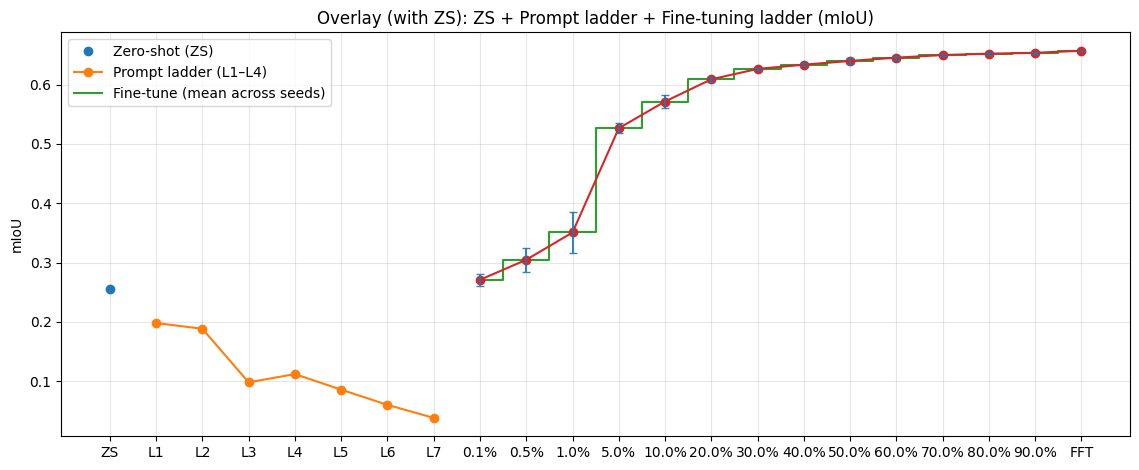

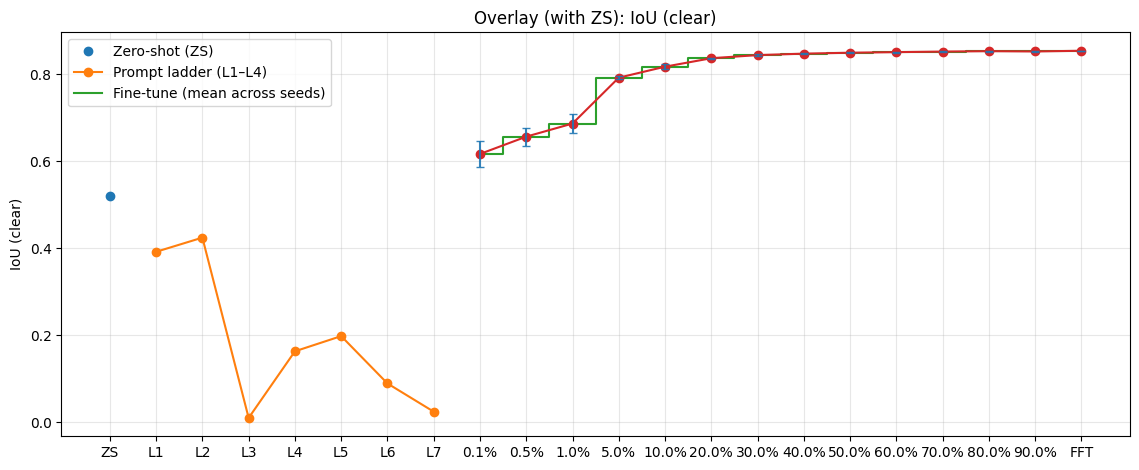

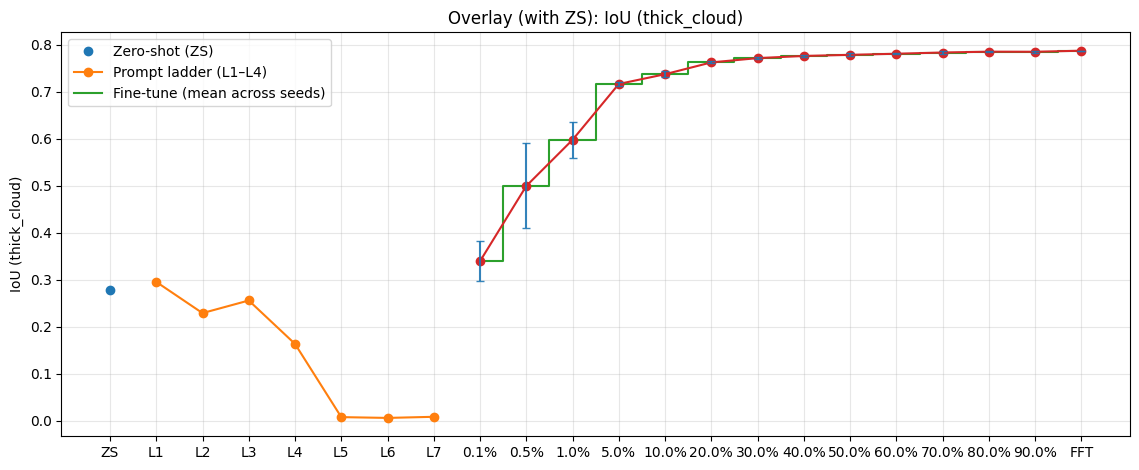

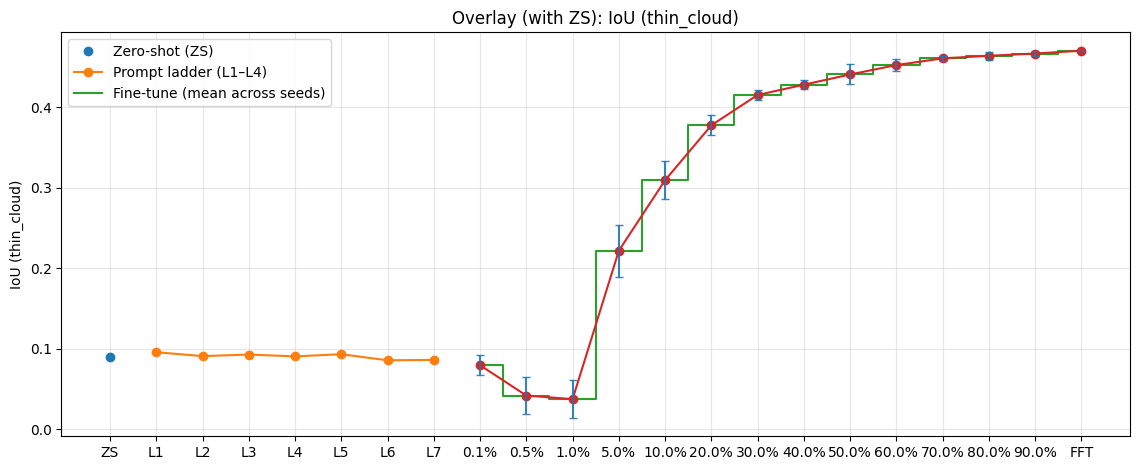

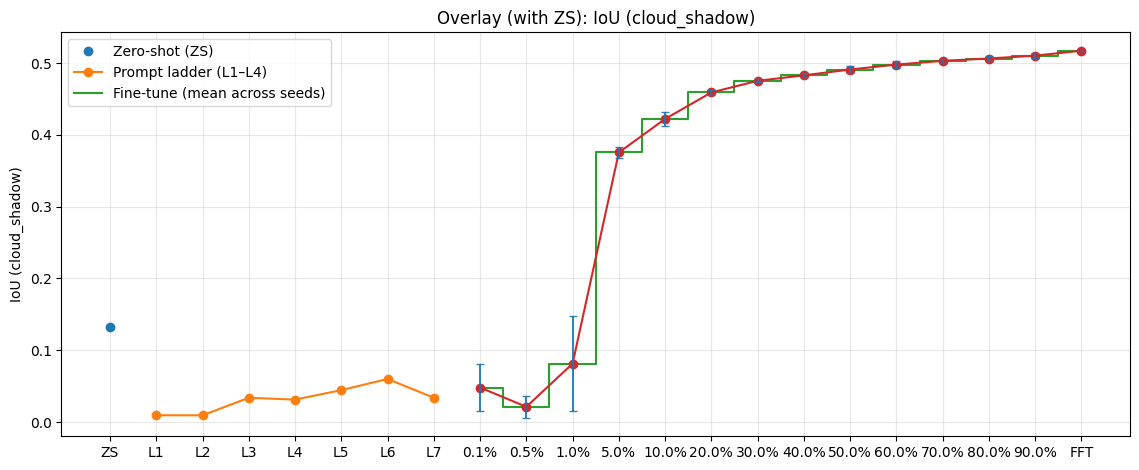

In [31]:
plot_overlay_with_zs("miou", "Overlay (with ZS): ZS + Prompt ladder + Fine-tuning ladder (mIoU)", "mIoU")

plot_overlay_with_zs("iou_clear", "Overlay (with ZS): IoU (clear)", "IoU (clear)")
plot_overlay_with_zs("iou_thick_cloud", "Overlay (with ZS): IoU (thick_cloud)", "IoU (thick_cloud)")
plot_overlay_with_zs("iou_thin_cloud", "Overlay (with ZS): IoU (thin_cloud)", "IoU (thin_cloud)")
plot_overlay_with_zs("iou_cloud_shadow", "Overlay (with ZS): IoU (cloud_shadow)", "IoU (cloud_shadow)")


- **Level 1**: Foundation (satellite context)
- **Level 2**: Adds color/brightness to Level 1
- **Level 3**: Adds texture to Level 1+2
- **Level 4**: Adds spatial relations to Level 1+2+3
- **Level 5**: Adds comparative anchors to Level 1+2+3+4
- **Level 6**: Adds physics terminology to Level 1+2+3+4+5
- **Level 7**: Adds analogies to Level 1+2+3+4+5+6



L1_PROMPTS=(
  "earth surface visible from satellite"
  "cloud from satellite view"
  "cloud layer from satellite view"
  "ground shadow in satellite image"
)

L2_PROMPTS=(
  "colorful earth surface with greens browns blues from satellite"
  "bright white cloud from satellite view"
  "pale gray cloud layer from satellite view"
  "very dark ground shadow in satellite image"
)

L3_PROMPTS=(
  "colorful earth surface with fine detailed texture, fields roads visible from satellite"
  "bright white cloud with smooth uniform texture from satellite view"
  "pale gray cloud layer with faded soft texture from satellite view"
  "very dark ground shadow with sharp crisp edges in satellite image"
)

L4_PROMPTS=(
  "colorful earth surface with fine detailed texture, fields roads visible, open sky above from satellite"
  "bright white cloud with smooth uniform texture, dark shadow region directly below, from satellite view"
  "pale gray cloud layer with faded soft texture, terrain visible beneath cloud, from satellite view"
  "very dark ground shadow with sharp crisp edges, bright white cloud adjacent above, satellite image"
)

L5_PROMPTS=(
  "colorful earth surface with fine detailed texture, fields roads visible, open sky above, moderate brightness from satellite"
  "brightest region, bright white cloud with smooth uniform texture, dark shadow directly below, from satellite view"
  "pale gray semi-transparent cloud layer, faded soft texture, terrain visible beneath, moderate brightness from satellite"
  "darkest region, very dark ground shadow with sharp crisp edges, bright cloud above, satellite image"
)

L6_PROMPTS=(
  "colorful earth surface, fine detailed texture, fields roads visible, open sky above, moderate brightness, natural surface reflectance from satellite"
  "brightest region, bright white highly reflective cloud, smooth texture, dark shadow below, opaque high albedo from satellite"
  "pale gray semi-transparent cloud, faded texture, terrain visible beneath, moderate brightness, partial light transmission from satellite"
  "darkest region, very dark ground shadow, sharp edges, bright cloud above, sunlight blocked minimal illumination, satellite image"
)

L7_PROMPTS=(
  "colorful earth surface, fine detailed texture, fields roads, open sky above, moderate brightness, natural surface reflectance, like aerial photography of farmland from satellite"
  "brightest region, bright white highly reflective cloud, smooth texture, dark shadow below, opaque high albedo, like white cotton or thick fog seen from above, satellite view"
  "pale gray semi-transparent cloud, faded texture, terrain beneath visible, moderate brightness, partial transmission, like frosted glass over landscape from satellite"
  "darkest region, very dark ground shadow, sharp crisp edges, bright cloud above, sunlight blocked, like deep shade cast on ground from above, satellite image"
)